In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch

In [3]:
# Generating datasets

# Deterministic set seed behavior

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [4]:
class Net(nn.Module):
    def __init__(self,input_dim,hidden_dim,out_dim=1,activation=nn.ReLU,drop_rate=0.0,batch_norm=False):
        super().__init__()
        layers = []
        current_dim = input_dim
        for h_dim in hidden_dim:
            layers.append(nn.Linear(current_dim,h_dim))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h_dim))
            layers.append(activation())
            if drop_rate>0:
                layers.append(nn.Dropout(drop_rate))
            current_dim=h_dim
        layers.append(nn.Linear(current_dim,out_dim))
        self.network = nn.Sequential(*layers)
        self.loss_history = []
        self.grad_history = []

    def forward(self,X):
        return self.network(X)
    
    def fit(self,loader,optim=torch.optim.Adam,crit=nn.MSELoss,epochs=500,lr=0.0001,early_stopping=False,patience=10,min_delta=0.0,log_grads=False,clip=False, **kwargs):
        self.train()

        criterion = crit()
        optimizer = optim(self.parameters(),lr=lr, **kwargs)

        self.loss_history = []
        self.grad_history = []
        best_loss = np.inf 
        no_improve = 0

        for epoch in range(epochs):
            epoch_loss = 0.0
            epoch_grad_sums = {}
            batch_count = 0
            for batch_x,batch_y in loader:
                optimizer.zero_grad()
                loss = criterion(self(batch_x),batch_y)

                loss.backward()
                if clip==True:
                    torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
                if log_grads:
                    for name,p in self.named_parameters():
                        if p.grad is not None and "weight" in name:
                            g = torch.norm(p.grad).item()
                            if name in epoch_grad_sums:
                                epoch_grad_sums[name] += g
                            else:
                                epoch_grad_sums[name] = g

                optimizer.step()
                epoch_loss += loss.item()
                batch_count += 1

            epoch_loss /= max(batch_count,1)
            self.loss_history.append(epoch_loss)

            if log_grads and batch_count>0:
                avg_grads = {k:v/batch_count for k,v in epoch_grad_sums.items()}
                self.grad_history.append(avg_grads)

            if epoch_loss + min_delta < best_loss:
                best_loss = epoch_loss
                no_improve = 0
            else:
                no_improve += 1
                if early_stopping and no_improve>=patience:
                    break

        return best_loss
    
    def evaluate(self, loader, crit=nn.MSELoss):
        self.eval()
        criterion = crit()
        total_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in loader:
                loss = criterion(self(batch_x), batch_y)
                total_loss += loss.item()
        
        return total_loss / len(loader)
    def predict(self,x):
        self.eval()
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32)
        with torch.no_grad():
            return self(x)

def plot_history(model):

    epochs = range(1,len(model.loss_history)+1)
    fig,axes = plt.subplots(1,2,figsize=(12,4))
    ax1,ax2 = axes
    ax1.plot(epochs,model.loss_history)
    ax1.set_title("Training loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    if model.grad_history:
        keys = list(model.grad_history[0].keys())
        for k in keys:
            ax2.plot(range(1,len(model.grad_history)+1),[g.get(k,0.0) for g in model.grad_history],label=k)
        ax2.set_title("Gradient norms")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Norm")
        ax2.legend()

    else:
        ax2.axis("off")
    plt.tight_layout()
    plt.show()

In [18]:
# regression dataset
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader,TensorDataset
X,y = make_regression(n_samples=200,n_features=20,n_informative=5,random_state=42)
    
# Standardize features - 0 mean, unit variance
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).view(-1,1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).view(-1,1)

batch_size = 32
train_dataset = TensorDataset(X_train,y_train)
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)

test_dataset = TensorDataset(X_test,y_test)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

Training loss: 0.05717570185661316
Test loss: 0.17336473613977432


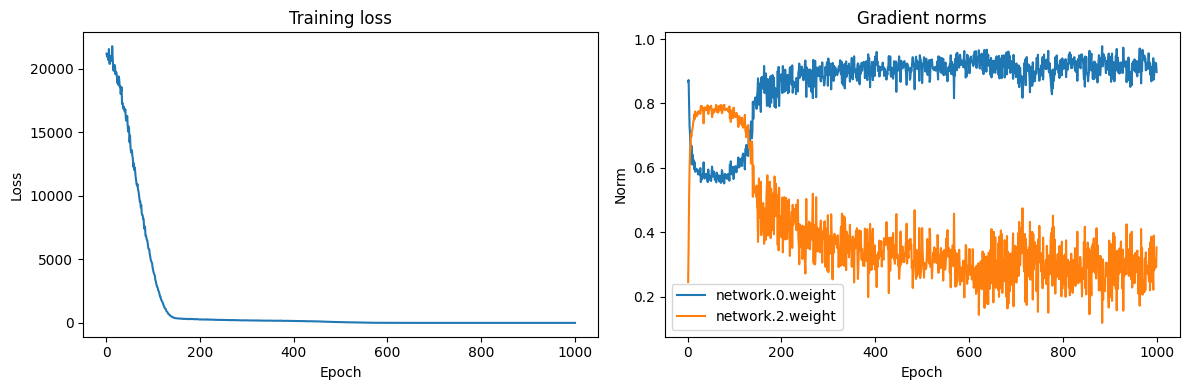

{'network.0.weight': 0.8974944710731506, 'network.2.weight': 0.3534666270017624}


In [29]:
hidden_dim = [3]
model = Net(input_dim=X_train.shape[1],hidden_dim=hidden_dim,activation=nn.ReLU,drop_rate=0.0,batch_norm=False)
loss = model.fit(train_loader,
                 optim=torch.optim.Adam,
                 crit=nn.MSELoss,
                 epochs=1000,
                 lr=0.01,
                #  momentum=0.9,
                #  early_stopping=True,
                #  betas=(0.8, 0.999),
                #  patience=20,
                #  min_delta=1e-4,
                 log_grads=True,
                 weight_decay=1e-2,
                 clip=True
                 )

test_loss = model.evaluate(test_loader,crit=nn.MSELoss)

print("Training loss:",loss)
print("Test loss:",test_loss)
plot_history(model)
print(model.grad_history[-1])

In [7]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X_clf,y_clf = make_moons(n_samples=400,noise=0.2,random_state=42)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf,y_clf,test_size=0.25,random_state=42)

X_train_clf = torch.FloatTensor(X_train_clf)
y_train_clf = torch.FloatTensor(y_train_clf).view(-1,1)
X_test_clf = torch.FloatTensor(X_test_clf)
y_test_clf = torch.FloatTensor(y_test_clf).view(-1,1)

batch_size_clf = 32
train_dataset_clf = TensorDataset(X_train_clf,y_train_clf)
train_loader_clf = DataLoader(train_dataset_clf,batch_size=batch_size_clf,shuffle=True)

test_dataset_clf = TensorDataset(X_test_clf,y_test_clf)
test_loader_clf = DataLoader(test_dataset_clf,batch_size=batch_size_clf,shuffle=False)


Training loss: 0.06215227395296097
Test loss: 0.08178160432726145
Test accuracy: 0.96


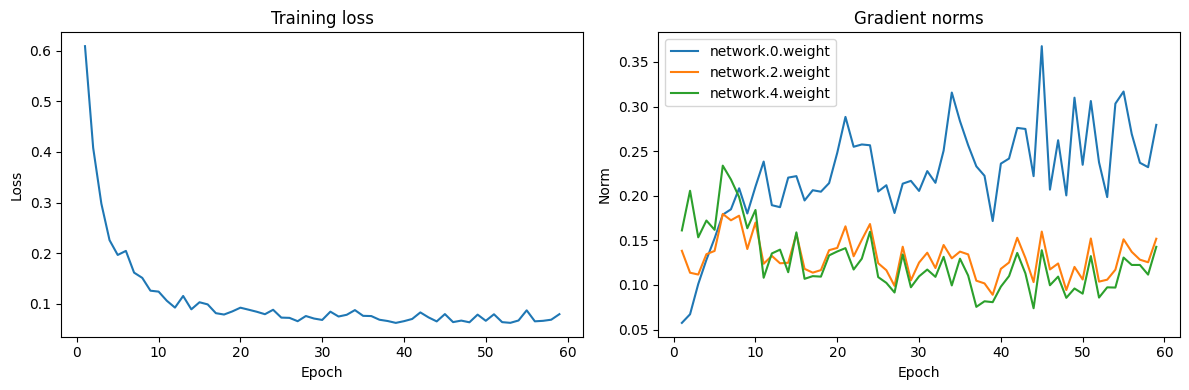

In [8]:
hidden_dim_clf = [32,16]

model_clf = Net(
    input_dim=X_train_clf.shape[1],
    hidden_dim=hidden_dim_clf,
    out_dim=1,
    activation=nn.ReLU,
    drop_rate=0.0,
    batch_norm=False
)

loss_clf = model_clf.fit(
    train_loader_clf,
    optim=torch.optim.Adam,
    crit=nn.BCEWithLogitsLoss,
    epochs=300,
    lr=0.01,
    early_stopping=True,
    patience=20,
    min_delta=1e-4,
    log_grads=True
)

test_loss_clf = model_clf.evaluate(
    test_loader_clf,
    crit=nn.BCEWithLogitsLoss
)

correct = 0
total = 0

model_clf.eval()
with torch.no_grad():
    for x,y in test_loader_clf:
        logits = model_clf(x)
        preds = torch.sigmoid(logits) > 0.5
        correct += (preds.float() == y).sum().item()
        total += y.size(0)

accuracy_clf = correct / total

print("Training loss:", loss_clf)
print("Test loss:", test_loss_clf)
print("Test accuracy:", accuracy_clf)

plot_history(model_clf)

In [9]:
from torchvision import datasets,transforms
g = torch.Generator()
g.manual_seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x))
])

train_data = datasets.MNIST(root='./data',train=True,download=True,transform=transform)
test_data = datasets.MNIST(root='./data',train=False,download=True,transform=transform)

train_loader_mnist = torch.utils.data.DataLoader(train_data,batch_size=64,shuffle=True,generator=g)
test_loader_mnist = torch.utils.data.DataLoader(test_data,batch_size=64,shuffle=False)


Training loss: 0.02063655339004008
Test loss: 0.08149206654445244
Test accuracy: 0.9791


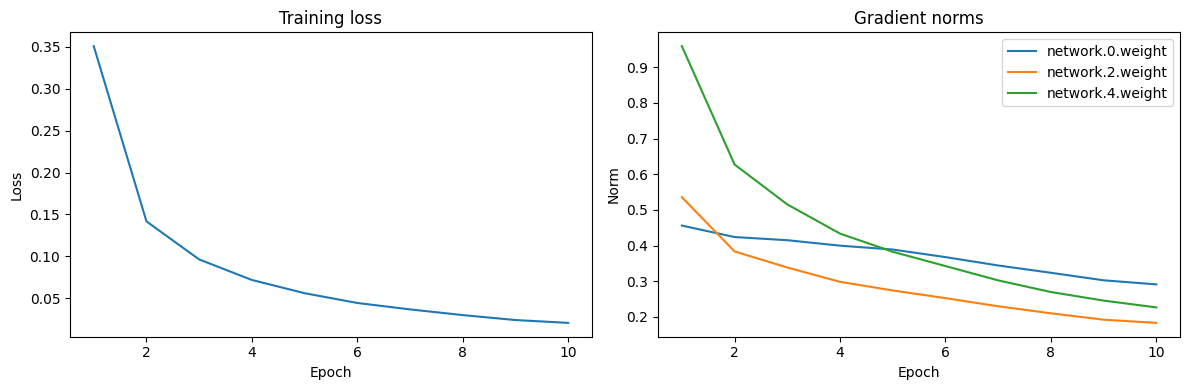

In [10]:
hidden_dim_mnist = [128,64]

model_mnist = Net(
    input_dim=28*28,
    hidden_dim=hidden_dim_mnist,
    out_dim=10,
    activation=nn.ReLU,
    drop_rate=0.0,
    batch_norm=False
)

loss_mnist = model_mnist.fit(
    train_loader_mnist,
    optim=torch.optim.Adam,
    crit=nn.CrossEntropyLoss,
    epochs=10,
    lr=0.001,
    early_stopping=True,
    patience=3,
    min_delta=1e-4,
    log_grads=True
)

test_loss_mnist = model_mnist.evaluate(
    test_loader_mnist,
    crit=nn.CrossEntropyLoss
)

correct = 0
total = 0

model_mnist.eval()
with torch.no_grad():
    for x,y in test_loader_mnist:
        outputs = model_mnist(x)
        preds = torch.argmax(outputs,dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

accuracy = correct/total

print("Training loss:", loss_mnist)
print("Test loss:", test_loss_mnist)
print("Test accuracy:", accuracy)

plot_history(model_mnist)